## Installation

In [ ]:
!pip install mlxtend

## 1. Importing

In [1]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
transactions = [
    ['Bread', 'Milk'],
    ['Bread', 'Diaper', 'Beer', 'Eggs'],
    ['Milk', 'Diaper', 'Beer', 'Coke'],
    ['Bread', 'Milk', 'Diaper', 'Beer'],
    ['Bread', 'Milk', 'Diaper', 'Coke']
]

In [3]:
transactions

[['Bread', 'Milk'],
 ['Bread', 'Diaper', 'Beer', 'Eggs'],
 ['Milk', 'Diaper', 'Beer', 'Coke'],
 ['Bread', 'Milk', 'Diaper', 'Beer'],
 ['Bread', 'Milk', 'Diaper', 'Coke']]

In [5]:
for i, t in enumerate(transactions, start=1):
    print(f"T{i}: {t}")

T1: ['Bread', 'Milk']
T2: ['Bread', 'Diaper', 'Beer', 'Eggs']
T3: ['Milk', 'Diaper', 'Beer', 'Coke']
T4: ['Bread', 'Milk', 'Diaper', 'Beer']
T5: ['Bread', 'Milk', 'Diaper', 'Coke']


## 3. Extract Feature

In [6]:
# Convert transaction data into one-hot encoded format
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

# Create DataFrame
df = pd.DataFrame(te_data, columns=te.columns_)
df

,Beer,Bread,Coke,Diaper,Eggs,Milk
0,False,True,False,False,False,True
1,True,True,False,True,True,False
2,True,False,True,True,False,True
3,True,True,False,True,False,True
4,False,True,True,True,False,True


In [7]:
df.sum()

Beer      3
Bread     4
Coke      2
Diaper    4
Eggs      1
Milk      4
dtype: int64

## 4. Preprocess Data

- Data is already preprocessed using one-hot encoding
- Boolean values are acceptable for Apriori

## 5. Split the Data into Training and Test Sets
- Apriori is an unsupervised learning algorithm.
- Therefore, train-test splitting is generally not required.

## 6. Define Model

In [8]:
min_support_value = 0.6

## 7. Train the Model

In [9]:
# Generate frequent itemsets
frequent_itemsets = apriori(
    df,
    min_support=min_support_value,
    use_colnames=True
)
frequent_itemsets

,support,itemsets
0,0.6,frozenset({Beer})
1,0.8,frozenset({Bread})
2,0.8,frozenset({Diaper})
3,0.8,frozenset({Milk})
4,0.6,"frozenset({Diaper, Beer})"
5,0.6,"frozenset({Bread, Diaper})"
6,0.6,"frozenset({Milk, Bread})"
7,0.6,"frozenset({Milk, Diaper})"


### 7.1 Separate 1-itemsets, 2-itemsets, 3-itemsets

In [10]:
# Add length column
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

# Frequent 1-itemsets
L1 = frequent_itemsets[frequent_itemsets['length'] == 1]

# Frequent 2-itemsets
L2 = frequent_itemsets[frequent_itemsets['length'] == 2]

# Frequent 3-itemsets
L3 = frequent_itemsets[frequent_itemsets['length'] == 3]

In [11]:
frequent_itemsets

,support,itemsets,length
0,0.6,frozenset({Beer}),1
1,0.8,frozenset({Bread}),1
2,0.8,frozenset({Diaper}),1
3,0.8,frozenset({Milk}),1
4,0.6,"frozenset({Diaper, Beer})",2
5,0.6,"frozenset({Bread, Diaper})",2
6,0.6,"frozenset({Milk, Bread})",2
7,0.6,"frozenset({Milk, Diaper})",2


In [12]:
L1

,support,itemsets,length
0,0.6,frozenset({Beer}),1
1,0.8,frozenset({Bread}),1
2,0.8,frozenset({Diaper}),1
3,0.8,frozenset({Milk}),1


In [13]:
L2

,support,itemsets,length
4,0.6,"frozenset({Diaper, Beer})",2
5,0.6,"frozenset({Bread, Diaper})",2
6,0.6,"frozenset({Milk, Bread})",2
7,0.6,"frozenset({Milk, Diaper})",2


In [14]:
L3

,support,itemsets,length


### 7.2 Association Rule

| Column Name            | Type  | Meaning                       | Formula / Explanation                  |
| ---------------------- | ----- | ----------------------------- | -------------------------------------- |
| **antecedents**        | set   | IF part of the rule           | Items on the left side (A)             |
| **consequents**        | set   | THEN part of the rule         | Items on the right side (B)            |
| **antecedent support** | float | Frequency of A alone          | support(A) = A / total transactions    |
| **consequent support** | float | Frequency of B alone          | support(B)                             |
| **support**            | float | Frequency of A and B together | support(A ∪ B)                         |
| **confidence**         | float | Reliability of rule           | support(A ∪ B) / support(A)            |
| **lift**               | float | Strength of association       | confidence / support(B)                |
| **leverage**           | float | Difference from independence  | support(A ∪ B) − support(A)×support(B) |
| **conviction**         | float | Rule reliability measure      | (1 − support(B)) / (1 − confidence)    |


In [15]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Diaper}),frozenset({Beer}),0.8,0.6,0.6,0.75,1.2500,1.0,0.12,1.6,1.00,0.75,0.375,0.875
1,frozenset({Beer}),frozenset({Diaper}),0.6,0.8,0.6,1.00,1.2500,1.0,0.12,inf,0.50,0.75,1.000,0.875
2,frozenset({Bread}),frozenset({Diaper}),0.8,0.8,0.6,0.75,0.9375,1.0,-0.04,0.8,-0.25,0.60,-0.250,0.750
3,frozenset({Diaper}),frozenset({Bread}),0.8,0.8,0.6,0.75,0.9375,1.0,-0.04,0.8,-0.25,0.60,-0.250,0.750
4,frozenset({Milk}),frozenset({Bread}),0.8,0.8,0.6,0.75,0.9375,1.0,-0.04,0.8,-0.25,0.60,-0.250,0.750
5,frozenset({Bread}),frozenset({Milk}),0.8,0.8,0.6,0.75,0.9375,1.0,-0.04,0.8,-0.25,0.60,-0.250,0.750
6,frozenset({Milk}),frozenset({Diaper}),0.8,0.8,0.6,0.75,0.9375,1.0,-0.04,0.8,-0.25,0.60,-0.250,0.750
7,frozenset({Diaper}),frozenset({Milk}),0.8,0.8,0.6,0.75,0.9375,1.0,-0.04,0.8,-0.25,0.60,-0.250,0.750


## 8. Make Predictions

**Example Prediction**
- If a customer buys Bread and Milk,
- what else is likely to be purchased?

In [19]:
for i, row in rules.iterrows():

    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))

    print(f"IF [{antecedents}] THEN [{consequents}]")
    print(f"Support: {row['support']:.2f}")
    print(f"Confidence: {row['confidence']:.2f}")
    print(f"Lift: {row['lift']:.2f}")
    print("-" * 50)

IF [Diaper] THEN [Beer]
Support: 0.60
Confidence: 0.75
Lift: 1.25
--------------------------------------------------
IF [Beer] THEN [Diaper]
Support: 0.60
Confidence: 1.00
Lift: 1.25
--------------------------------------------------
IF [Bread] THEN [Diaper]
Support: 0.60
Confidence: 0.75
Lift: 0.94
--------------------------------------------------
IF [Diaper] THEN [Bread]
Support: 0.60
Confidence: 0.75
Lift: 0.94
--------------------------------------------------
IF [Milk] THEN [Bread]
Support: 0.60
Confidence: 0.75
Lift: 0.94
--------------------------------------------------
IF [Bread] THEN [Milk]
Support: 0.60
Confidence: 0.75
Lift: 0.94
--------------------------------------------------
IF [Milk] THEN [Diaper]
Support: 0.60
Confidence: 0.75
Lift: 0.94
--------------------------------------------------
IF [Diaper] THEN [Milk]
Support: 0.60
Confidence: 0.75
Lift: 0.94
--------------------------------------------------


## 9. Evaluate the Model

Apriori algorithm is evaluated using support, confidence, and lift. High confidence and lift values indicate strong and meaningful association rules.

In [20]:
# Filter strong rules
strong_rules = rules[
    (rules['confidence'] >= 0.7) &
    (rules['lift'] > 1)
]
strong_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Diaper}),frozenset({Beer}),0.8,0.6,0.6,0.75,1.25,1.0,0.12,1.6,1.0,0.75,0.375,0.875
1,frozenset({Beer}),frozenset({Diaper}),0.6,0.8,0.6,1.00,1.25,1.0,0.12,inf,0.5,0.75,1.000,0.875


In [21]:
print(f"Total Rules Generated : {len(rules)}")
print(f"Strong Rules Found    : {len(strong_rules)}")

print("\nAverage Confidence :", round(rules['confidence'].mean(), 2))
print("Average Lift       :", round(rules['lift'].mean(), 2))
print("Average Support    :", round(rules['support'].mean(), 2))

Total Rules Generated : 8
Strong Rules Found    : 2

Average Confidence : 0.78
Average Lift       : 1.02
Average Support    : 0.6


## 10. Visualization

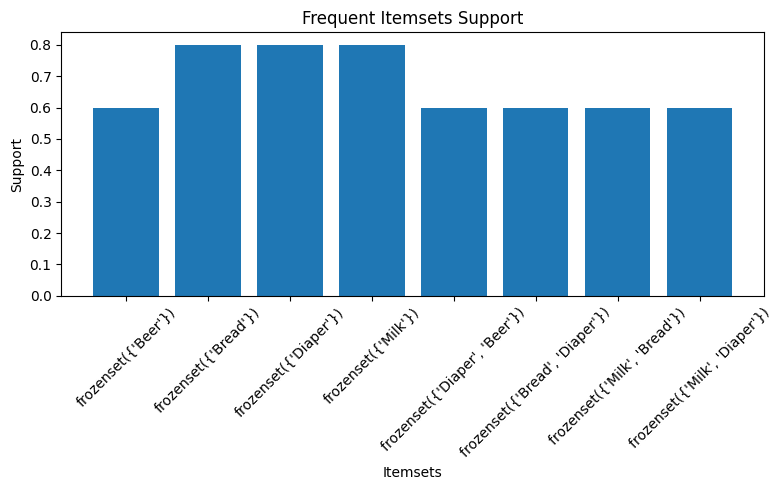

In [22]:
plt.figure(figsize=(8, 5))

itemsets = frequent_itemsets['itemsets'].astype(str)
supports = frequent_itemsets['support']

plt.bar(itemsets, supports)

plt.title("Frequent Itemsets Support")
plt.xlabel("Itemsets")
plt.ylabel("Support")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()